# Imports

In [173]:
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
from torch.nn import Sequential, Linear, Dropout, ReLU
from sklearn.metrics import accuracy_score
from torch.optim import Adam, RMSprop, SGD

In [190]:
N_FEATURES = 2
FIRST_LAYER_SIZE = 100
SECOND_LAYER_SIZE = 300
THIRD_LAYER_SIZE = 100
OUTPUT_SIZE = 1
TEST_SIZE = 0.2
EPOCH = 1000
LR = 1e-2
BATCH_SIZE = 64

# Dataset

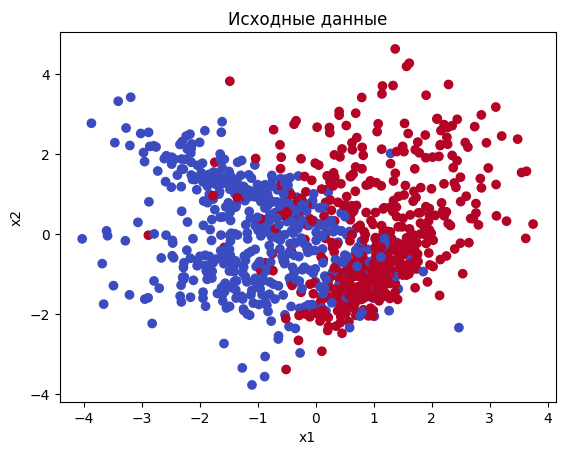

In [175]:
X, y = make_classification(
    n_samples=1000,
    n_features=N_FEATURES,
    n_informative=2,
    n_redundant=0,
    n_repeated=0,
    n_classes=2,
    random_state=1
)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm')
plt.title('Исходные данные')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

# MLP

In [176]:
model = Sequential(
    Linear(N_FEATURES, FIRST_LAYER_SIZE),
    ReLU(),

    Linear(FIRST_LAYER_SIZE, SECOND_LAYER_SIZE),
    ReLU(),

    Linear(SECOND_LAYER_SIZE, THIRD_LAYER_SIZE),
    ReLU(),

    Linear(THIRD_LAYER_SIZE, OUTPUT_SIZE)
)

In [198]:
def pipeline(model, X_train, y_train, X_test, y_test, opt):
    losses = []

    optimizer = opt(model.parameters())

    for i in range(EPOCH):
        ix = torch.randint(0, X_train.shape[0], (BATCH_SIZE,))

        optimizer.zero_grad()

        xi, yi = X_train[ix], y_train[ix]
        xi = model(xi)

        probs = F.sigmoid(xi)

        loss = F.binary_cross_entropy(probs, yi)
        losses.append(loss.detach())

        loss.backward()
        optimizer.step()

    plt.plot(torch.tensor(losses))

    acc = 0
    with torch.no_grad():
        xi = X_test
        xi = model(xi)

        predictions = (xi > 0.5).float()
        acc = accuracy_score(y_test.numpy(), predictions.numpy())
    print(f'Accuracy: {acc}')

In [199]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=1)

Accuracy: 0.855


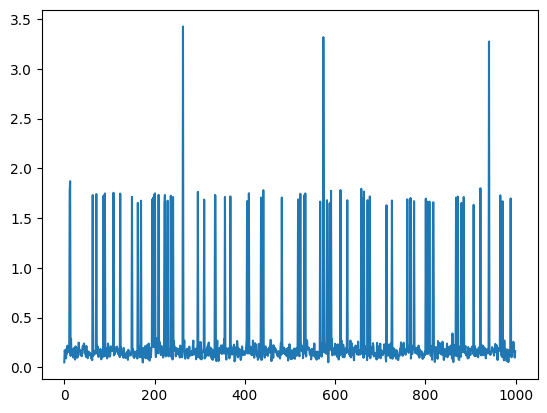

In [204]:
pipeline(model, X_train, y_train, X_test, y_test, SGD)

Accuracy: 0.85


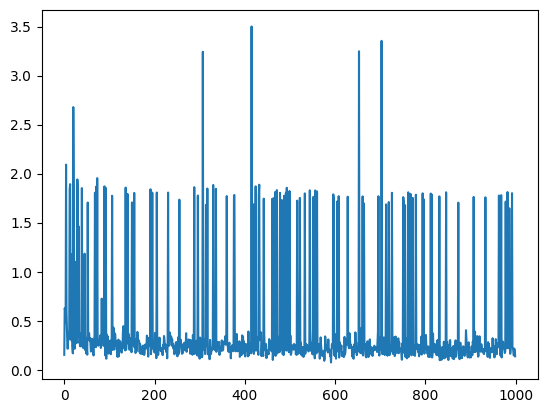

In [205]:
pipeline(model, X_train, y_train, X_test, y_test, RMSprop)

Accuracy: 0.855


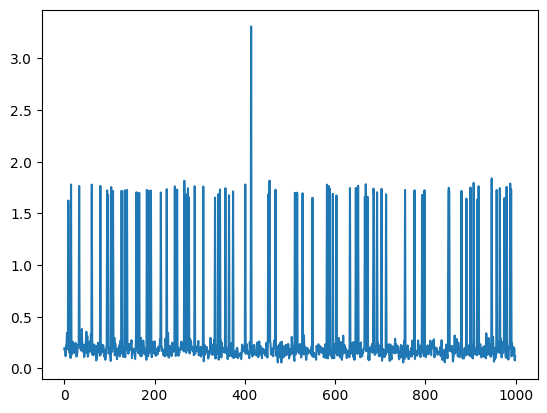

In [206]:
pipeline(model, X_train, y_train, X_test, y_test, Adam)

# Вывод по оптимизационным алгоритмам

Из за простоты модели особо разницы между данными алгоритмами нет. Но в среднем RMSprop и Adam сходятся быстрее и точнее нежели SGD.

# Dropout

In [215]:
model = Sequential(
    Linear(N_FEATURES, FIRST_LAYER_SIZE),
    ReLU(),
    Dropout(p=0.5),

    Linear(FIRST_LAYER_SIZE, SECOND_LAYER_SIZE),
    ReLU(),
    Dropout(p=0.5),

    Linear(SECOND_LAYER_SIZE, THIRD_LAYER_SIZE),
    ReLU(),
    Dropout(p=0.5),

    Linear(THIRD_LAYER_SIZE, OUTPUT_SIZE)
)

In [216]:
def pipeline(model, X_train, y_train, X_test, y_test, opt):
    losses = []

    optimizer = opt(model.parameters(), weight_decay=1e-4)

    for i in range(EPOCH):
        ix = torch.randint(0, X_train.shape[0], (BATCH_SIZE,))

        optimizer.zero_grad()

        x, y = X_train[ix], y_train[ix]
        x = model(x)

        probs = F.sigmoid(x)

        loss = F.binary_cross_entropy(probs, y)
        losses.append(loss.detach())

        loss.backward()
        optimizer.step()

    plt.plot(torch.tensor(losses))

    acc = 0
    with torch.no_grad():
        x = X_test
        x = model(x)

        predictions = (x > 0.5).float()
        acc = accuracy_score(y_test.numpy(), predictions.numpy())
    print(f'Accuracy: {acc}')

Accuracy: 0.505


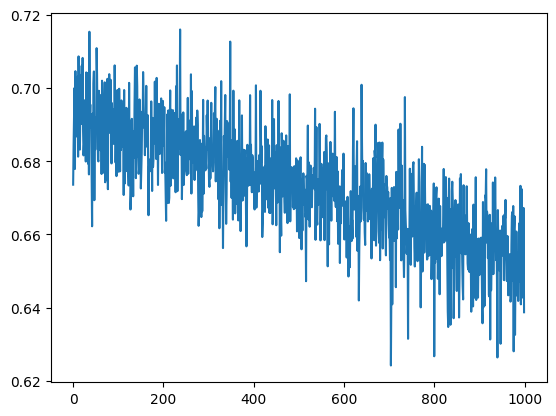

In [217]:
pipeline(model, X_train, y_train, X_test, y_test, SGD)

Accuracy: 0.84


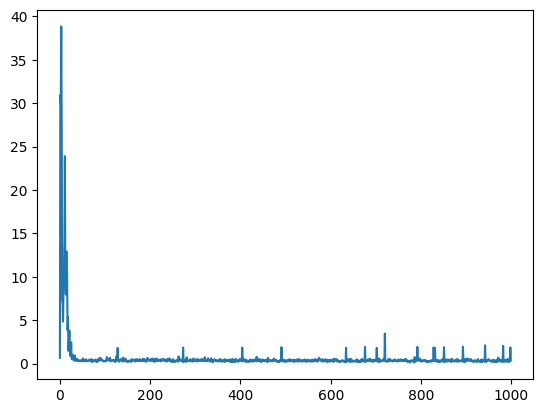

In [218]:
pipeline(model, X_train, y_train, X_test, y_test, RMSprop)

Accuracy: 0.88


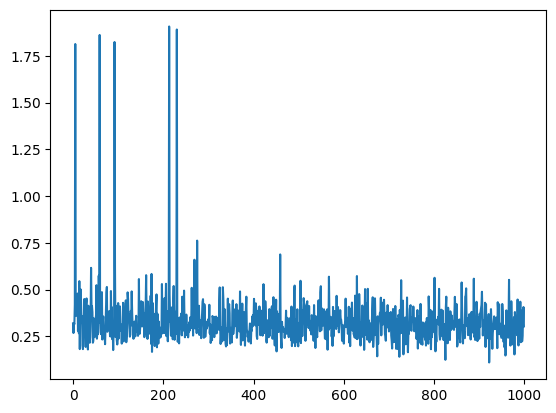

In [219]:
pipeline(model, X_train, y_train, X_test, y_test, Adam)

# Вывод по Dropout

Эффект от дропаута - сильная регуляризация. Видим, что стало меньше шума.